## НЕ РАБОТАЕТ

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad
import scipy.special as sp

In [2]:
class PINN_GrindingModel(nn.Module):
    def __init__(self, layers, activation='tanh'):
        super(PINN_GrindingModel, self).__init__()
        
        self.layers = nn.ModuleList()
        self.activation = activation
        
        # Построение сети
        for i in range(len(layers)-1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))
            
        # Инициализация весов
        self.init_weights()
        
    def init_weights(self):
        for layer in self.layers:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)
    
    def forward(self, t, z):
        """Вход: t (время), z (координата вдоль мельницы)"""
        X = torch.cat([t, z], dim=1)
        
        for i, layer in enumerate(self.layers[:-1]):
            X = layer(X)
            if self.activation == 'tanh':
                X = torch.tanh(X)
            elif self.activation == 'sin':
                X = torch.sin(X)
                
        output = self.layers[-1](X)
        
        # Нейронная сеть предсказывает 3 значения:
        # 1. S(z,t) - удельная поверхность
        # 2. M(z,t) - масса материала на единицу длины
        # 3. L(z,t) - масса жидкости на единицу длины
        return output[:, 0:1], output[:, 1:2], output[:, 2:3]

In [3]:
class GrindingPINN:
    def __init__(self, layers, params):
        self.net = PINN_GrindingModel(layers)
        self.params = params  # Словарь с параметрами модели
        
        # Параметры из уравнений
        self.S_max = params['S_max']  # S_max
        self.k = params['k']  # константа скорости измельчения
        self.rho_m = params['rho_m']  # плотность материала
        self.rho_l = params['rho_l']  # плотность жидкости
        self.mu_v = params['mu_v']  # отношение скоростей
        self.phi_sh = params['phi_sh']  # объемная доля шаров
        self.A = params['A']  # площадь сечения
        
    def physics_loss(self, t, z):
        """
        Вычисление физических ограничений на основе уравнений
        """
        # Включаем градиенты
        t.requires_grad_(True)
        z.requires_grad_(True)
        
        # Предсказания нейросети
        S, M, L = self.net(t, z)
        
        # 1. Уравнение кинетики измельчения (32)
        # ∂S/∂t + v_m * ∂S/∂z = k(S_max - S)
        
        # Вычисляем градиенты
        dS_dt = grad(S, t, grad_outputs=torch.ones_like(S), 
                    create_graph=True)[0]
        dS_dz = grad(S, z, grad_outputs=torch.ones_like(S), 
                    create_graph=True)[0]
        
        # Скорость материала v_m = F_m / M
        # Для простоты возьмем среднюю скорость
        v_m = self.params['v_m_avg']
        
        # Физическое ограничение для S
        loss_s = dS_dt + v_m * dS_dz - self.k * (self.S_max - S)
        
        # 2. Уравнение переноса материала (26)
        # ∂M/∂t = -∂F_m/∂z
        dM_dt = grad(M, t, grad_outputs=torch.ones_like(M), 
                    create_graph=True)[0]
        dM_dz = grad(M, z, grad_outputs=torch.ones_like(M), 
                    create_graph=True)[0]
        
        # Поток материала F_m = v_m * M
        F_m = v_m * M
        dF_m_dz = grad(F_m, z, grad_outputs=torch.ones_like(F_m), 
                      create_graph=True)[0]
        
        loss_m = dM_dt + dF_m_dz
        
        # 3. Уравнение для жидкости (29)
        dL_dt = grad(L, t, grad_outputs=torch.ones_like(L), 
                    create_graph=True)[0]
        
        # Поток жидкости
        F_l = self.mu_v * F_m * (L / M)
        dF_l_dz = grad(F_l, z, grad_outputs=torch.ones_like(F_l), 
                      create_graph=True)[0]
        
        loss_l = dL_dt + dF_l_dz
        
        # 4. Алгебраическая связь (23)
        # M/ρ_m + L/ρ_l = (1 - φ_ш) * A
        loss_alg = (M/self.rho_m + L/self.rho_l) - (1 - self.phi_sh) * self.A
        
        return loss_s, loss_m, loss_l, loss_alg
    
    def boundary_conditions(self, t_in, z_in, t_bc, z_bc):
        """
        Граничные условия
        """
        # На входе (z=0)
        S_pred, M_pred, L_pred = self.net(t_in, z_in)
        
        # S(0,t) = S_in(t) - граничное условие (34)
        S_in = self.params['S_in_func'](t_in)
        loss_bc_s = S_pred - S_in
        
        # M(0,t) из уравнения (31)
        F_m_in = self.params['F_m_in_func'](t_in)
        F_l_in = self.params['F_l_in_func'](t_in)
        
        M_in = self.A * (1 - self.phi_sh) / (
            1/self.rho_m + (1/(self.mu_v * self.rho_l)) * (F_l_in / F_m_in)
        )
        loss_bc_m = M_pred - M_in
        
        # L(0,t) из уравнения (30)
        L_in = M_in * (1/self.mu_v) * (F_l_in / F_m_in)
        loss_bc_l = L_pred - L_in
        
        # Начальные условия (t=0)
        S0_pred, M0_pred, L0_pred = self.net(t_bc, z_bc)
        S0 = self.params['S0_func'](z_bc)
        M0 = self.params['M0_func'](z_bc)
        L0 = self.params['L0_func'](z_bc)
        
        loss_ic_s = S0_pred - S0
        loss_ic_m = M0_pred - M0
        loss_ic_l = L0_pred - L0
        
        return (loss_bc_s, loss_bc_m, loss_bc_l, 
                loss_ic_s, loss_ic_m, loss_ic_l)
    
    def train(self, epochs, lr=0.001):
        """
        Обучение модели
        """
        optimizer = optim.Adam(self.net.parameters(), lr=lr)
        
        # Генерация точек для обучения
        t_domain = torch.linspace(0, self.params['T_max'], 100).view(-1, 1)
        z_domain = torch.linspace(0, self.params['L_m'], 100).view(-1, 1)
        
        # Точки внутри области
        t_train = torch.rand(1000, 1) * self.params['T_max']
        z_train = torch.rand(1000, 1) * self.params['L_m']
        
        # Граничные точки
        t_in = torch.rand(500, 1) * self.params['T_max']  # z=0
        z_in = torch.zeros_like(t_in)
        
        # Начальные точки
        z_ic = torch.rand(500, 1) * self.params['L_m']  # t=0
        t_ic = torch.zeros_like(z_ic)
        
        for epoch in range(epochs):
            optimizer.zero_grad()
            
            # Физические ограничения
            loss_s, loss_m, loss_l, loss_alg = self.physics_loss(
                t_train, z_train
            )
            
            # Граничные и начальные условия
            (loss_bc_s, loss_bc_m, loss_bc_l,
             loss_ic_s, loss_ic_m, loss_ic_l) = self.boundary_conditions(
                t_in, z_in, t_ic, z_ic
            )
            
            # Суммарная функция потерь
            loss = (torch.mean(loss_s**2) + 
                    torch.mean(loss_m**2) + 
                    torch.mean(loss_l**2) +
                    torch.mean(loss_alg**2) +
                    torch.mean(loss_bc_s**2) +
                    torch.mean(loss_bc_m**2) +
                    torch.mean(loss_bc_l**2) +
                    torch.mean(loss_ic_s**2) +
                    torch.mean(loss_ic_m**2) +
                    torch.mean(loss_ic_l**2))
            
            loss.backward()
            optimizer.step()
            
            if epoch % 100 == 0:
                print(f'Epoch {epoch}, Loss: {loss.item():.6f}')
        
        return self.net

In [4]:
class FractionalCompositionModel:
    """
    Класс для связи удельной поверхности с фракционным составом
    на основе уравнения Розена-Раммлера (45) и (46)
    """
    def __init__(self, params):
        self.params = params
        
    def specific_surface_to_fraction(self, S, d_x):
        """
        Преобразование удельной поверхности в долю частиц
        проходящих через сито размера d_x
        Используем уравнение (46)
        """
        # Параметры распределения Розена-Раммлера
        a = self.params['a']
        n = self.params['n']
        rho = self.params['rho']
        
        # Решение уравнения (46) относительно x
        # S = (6*a * [-ln((1-x)/a)]^(1/n) * Γ(1-1/n)) / (ρ*d_x)
        
        gamma_val = sp.gamma(1 - 1/n)
        
        # Выражаем x из уравнения
        term = (S * rho * d_x) / (6 * a * gamma_val)
        ln_term = term ** n
        x = 1 - a * np.exp(-ln_term)
        
        return np.clip(x, 0, 1)
    
    def fraction_to_specific_surface(self, x, d_x):
        """
        Обратное преобразование: доля частиц -> удельная поверхность
        """
        a = self.params['a']
        n = self.params['n']
        rho = self.params['rho']
        gamma_val = sp.gamma(1 - 1/n)
        
        ln_term = -np.log((1 - x) / a)
        S = (6 * a * (ln_term ** (1/n)) * gamma_val) / (rho * d_x)
        
        return S

## Использование

In [5]:
# Параметры модели
params = {
    # Физические параметры
    'S_max': 5000.0,  # м²/кг
    'k': 0.05,  # 1/c
    'rho_m': 2700.0,  # кг/м³
    'rho_l': 1000.0,  # кг/м³
    'mu_v': 1.2,  # отношение скоростей
    'phi_sh': 0.4,  # объемная доля шаров
    'A': 1.0,  # м²
    'v_m_avg': 0.1,  # м/с
    'L_m': 5.0,  # м
    'T_max': 100.0,  # с
    
    # Граничные условия
    'S_in_func': lambda t: 1000.0 + 100*torch.sin(0.1*t),
    'F_m_in_func': lambda t: 10.0 + 2*torch.sin(0.05*t),
    'F_l_in_func': lambda t: 20.0 + 5*torch.cos(0.03*t),
    
    # Начальные условия
    'S0_func': lambda z: 1000.0 + 200*z,
    'M0_func': lambda z: 50.0 * torch.ones_like(z),
    'L0_func': lambda z: 100.0 * torch.ones_like(z),
}

# Создание и обучение модели
pinn = GrindingPINN(layers=[2, 50, 50, 50, 3], params=params)
trained_model = pinn.train(epochs=5000, lr=0.001)

Epoch 0, Loss: 3758841.000000
Epoch 100, Loss: 3684569.000000
Epoch 200, Loss: 3645051.500000
Epoch 300, Loss: 3608661.500000
Epoch 400, Loss: 3573596.000000
Epoch 500, Loss: 3539406.250000
Epoch 600, Loss: 3505904.500000
Epoch 700, Loss: 3472988.750000
Epoch 800, Loss: 3440598.000000
Epoch 900, Loss: 3408691.250000
Epoch 1000, Loss: 3377236.750000
Epoch 1100, Loss: 3346209.500000
Epoch 1200, Loss: 3315591.750000
Epoch 1300, Loss: 3285366.250000
Epoch 1400, Loss: 3255518.750000
Epoch 1500, Loss: 3226037.500000
Epoch 1600, Loss: 3196910.000000
Epoch 1700, Loss: 3168128.250000
Epoch 1800, Loss: 3139680.500000
Epoch 1900, Loss: 3111560.000000
Epoch 2000, Loss: 3083758.250000
Epoch 2100, Loss: 3056266.750000
Epoch 2200, Loss: 3029079.250000
Epoch 2300, Loss: 3002189.500000
Epoch 2400, Loss: 2975589.250000
Epoch 2500, Loss: 2949274.000000
Epoch 2600, Loss: 2923237.500000
Epoch 2700, Loss: 2897473.250000
Epoch 2800, Loss: 2871976.500000
Epoch 2900, Loss: 2846741.500000
Epoch 3000, Loss: 2821

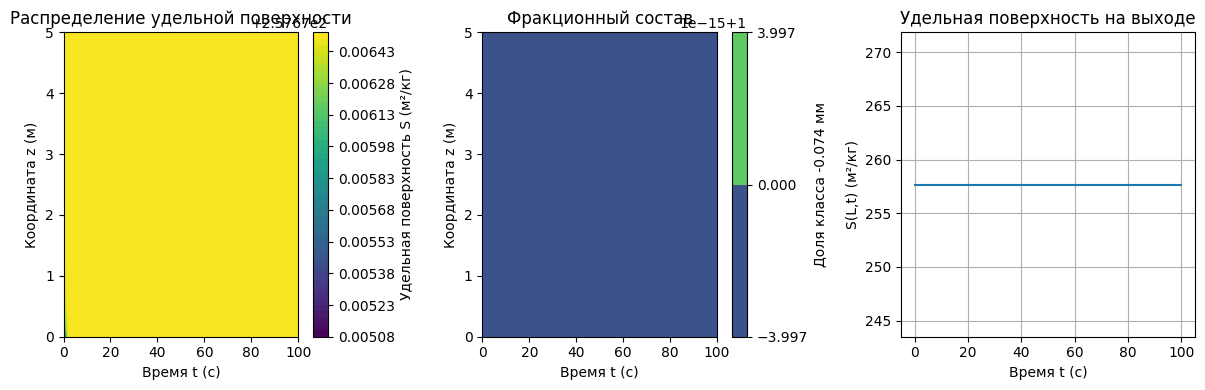

In [7]:
# Визуализация результатов
def visualize_results(model, params):
    t_test = torch.linspace(0, params['T_max'], 50)
    z_test = torch.linspace(0, params['L_m'], 50)
    
    T, Z = torch.meshgrid(t_test, z_test, indexing='ij')
    t_flat = T.flatten().unsqueeze(1)
    z_flat = Z.flatten().unsqueeze(1)
    
    with torch.no_grad():
        S_pred, M_pred, L_pred = model(t_flat, z_flat)
    
    S_pred = S_pred.reshape(50, 50)
    
    plt.figure(figsize=(12, 4))
    plt.subplot(131)
    plt.contourf(T.numpy(), Z.numpy(), S_pred.numpy(), levels=50)
    plt.colorbar(label='Удельная поверхность S (м²/кг)')
    plt.xlabel('Время t (с)')
    plt.ylabel('Координата z (м)')
    plt.title('Распределение удельной поверхности')
    
    # Пример использования для фракционного состава
    fraction_model = FractionalCompositionModel({
        'a': 0.95,
        'n': 1.2,
        'rho': params['rho_m']
    })
    
    # Расчет для заданного размера сита
    d_x = 0.074  # мм (сито 200 меш)
    fraction = fraction_model.specific_surface_to_fraction(
        S_pred.numpy(), d_x
    )
    
    plt.subplot(132)
    plt.contourf(T.numpy(), Z.numpy(), fraction, levels=50)
    plt.colorbar(label='Доля класса -0.074 мм')
    plt.xlabel('Время t (с)')
    plt.ylabel('Координата z (м)')
    plt.title('Фракционный состав')
    
    # Профиль на выходе из мельницы
    plt.subplot(133)
    z_out = params['L_m']
    z_tensor = torch.full_like(t_test.unsqueeze(1), z_out)
    S_out, _, _ = model(t_test.unsqueeze(1), z_tensor)
    
    plt.plot(t_test.detach().numpy(), S_out.detach().numpy())
    plt.xlabel('Время t (с)')
    plt.ylabel('S(L,t) (м²/кг)')
    plt.title('Удельная поверхность на выходе')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

visualize_results(trained_model, params)